In [2]:
import cvxpy as cp
import numpy as np
import pandas as pd
from cvxpy import psd_wrap
import matplotlib.pyplot as plt
from cvxpy.atoms.affine.wraps import psd_wrap
from sklearn.covariance import LedoitWolf
from plot_functions import plot_te_carbon_by_sector, plot_origin_vs_opt_weights_comparison, plot_te_carbon_heatmap
from tabulate import tabulate

| Term         | What to Use                                                     |
| ------------ | --------------------------------------------------------------- |
| `w_b_sector` | Benchmark weights **within the sector**, normalized to sum to 1 |
| `Σ_sector`   | Covariance matrix of sector constituents                        |
| `c_sector`   | Carbon intensities of sector companies                          |
| `w`          | Optimization variable: weights in sector                        |
| Constraints  | All operate **within** the sector universe                      |


# TE - CARBON FRONTIERS
No changes in the matrix, only clipping negative eigenvalues to 0:

| Sector                 |   Num Features |   Rank |   Min_Eigval1 |   Min_Eigval2 |   Min_Eigval3 |   Min_Eigval4 |   Min_Eigval5 | Low Rank?   | Not PSD?   |
|------------------------|----------------|--------|---------------|---------------|---------------|---------------|---------------|-------------|------------|
| Communication Services |             22 |     22 |   4.89645e-05 |   6.95918e-05 |   0.000158415 |   0.000324683 |   0.000469213 | False       | False      |
| Consumer Discretionary |             52 |     24 |  -6.27257e-18 |  -5.10291e-18 |  -4.15191e-18 |  -2.91039e-18 |  -2.30768e-18 | True        | False      |
| Consumer Staples       |             37 |     24 |  -4.94994e-18 |  -2.23947e-18 |  -1.82351e-18 |  -1.21667e-18 |  -1.98333e-20 | True        | False      |
| Energy                 |             23 |     23 |   2.2278e-05  |   2.96038e-05 |   7.50102e-05 |   9.13723e-05 |   0.000236027 | False       | False      |
| Financials             |             7

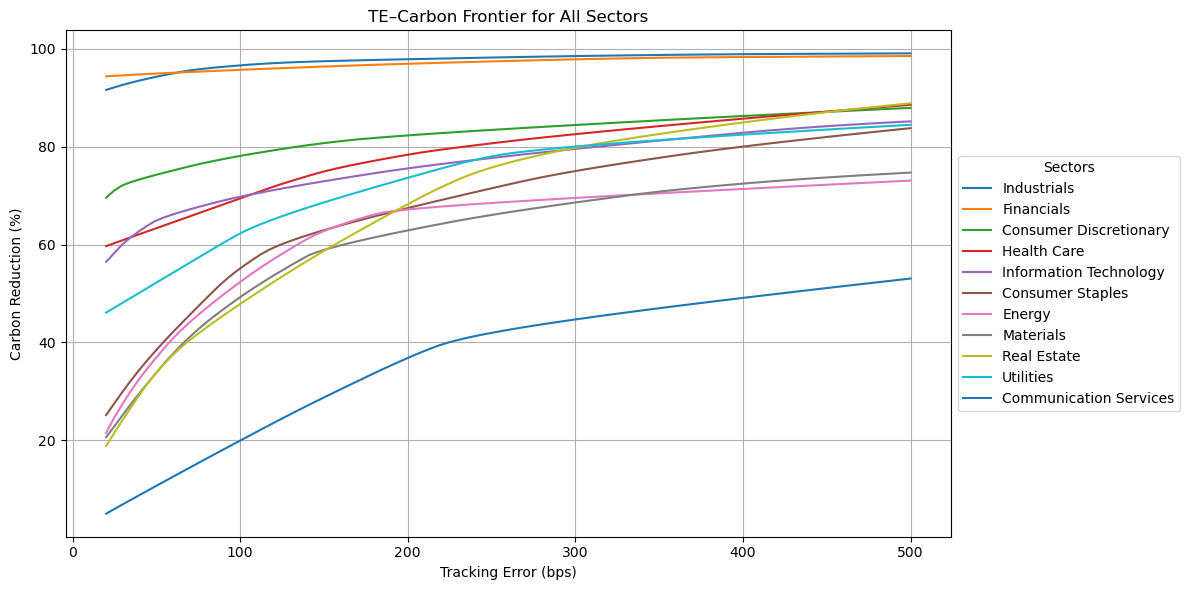

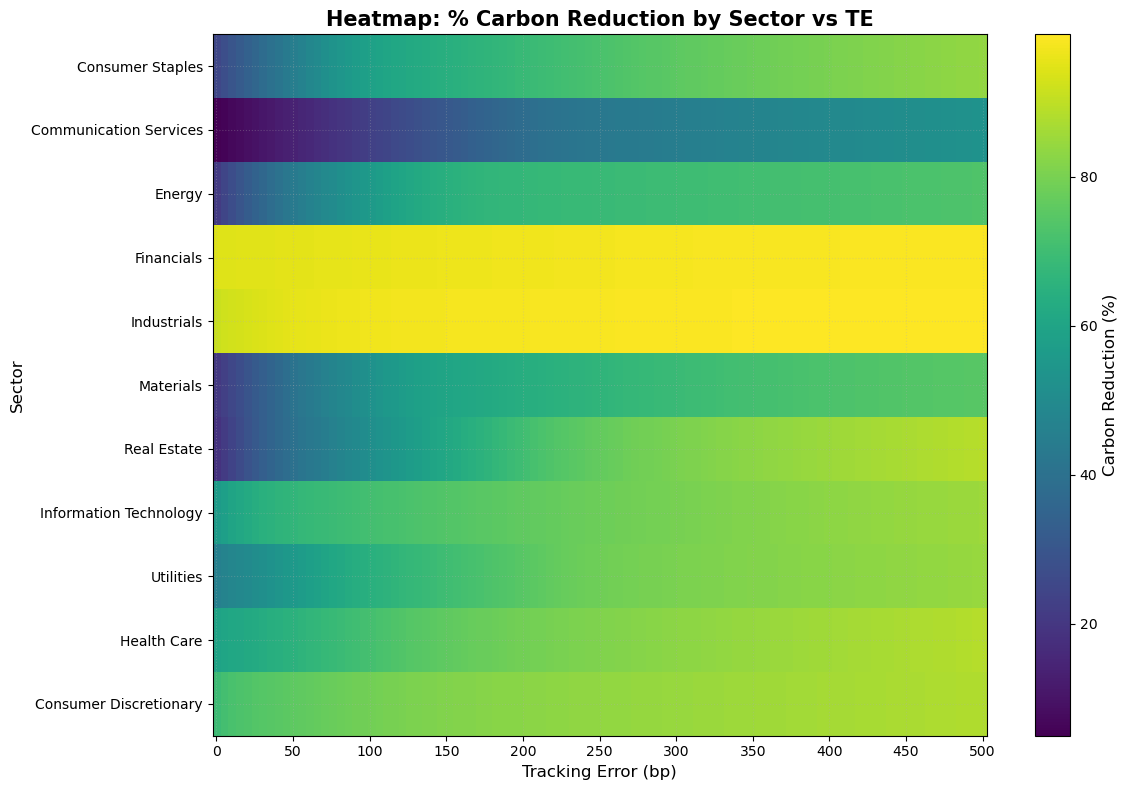

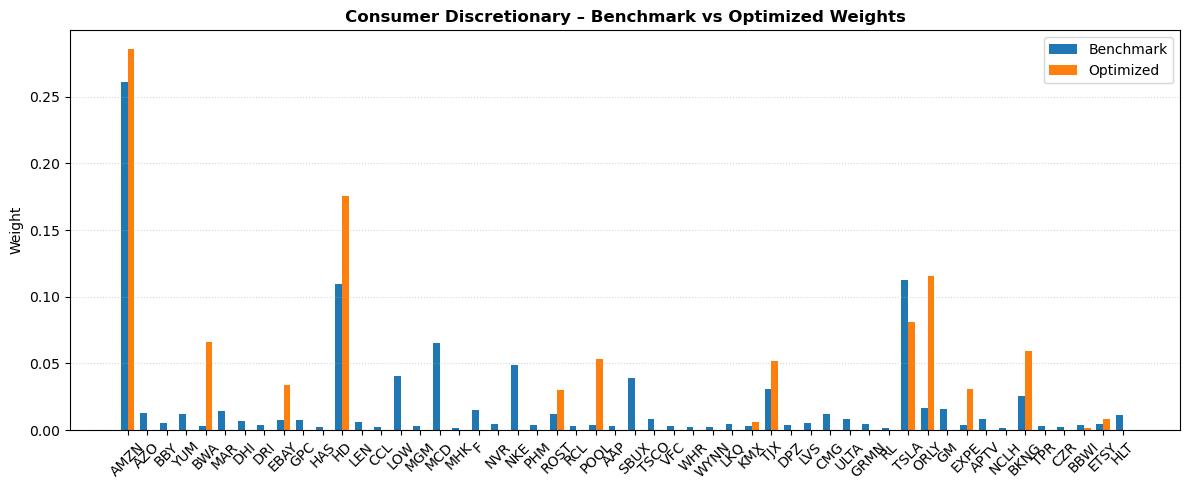

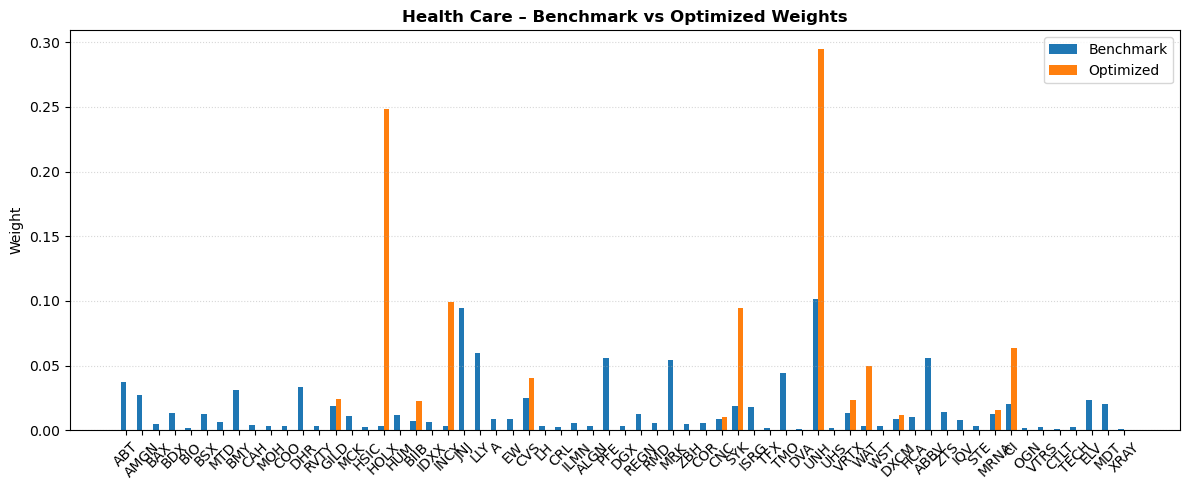

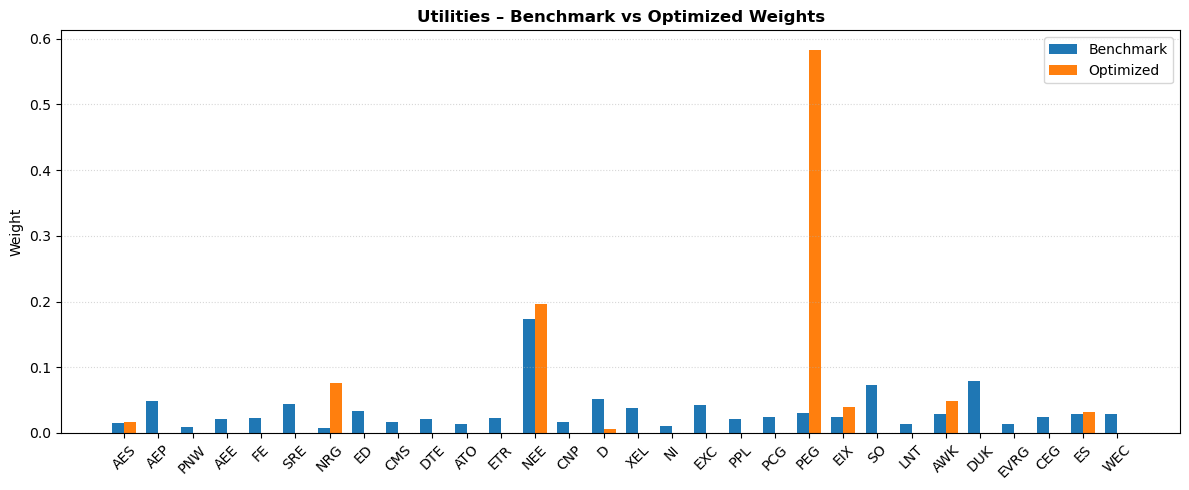

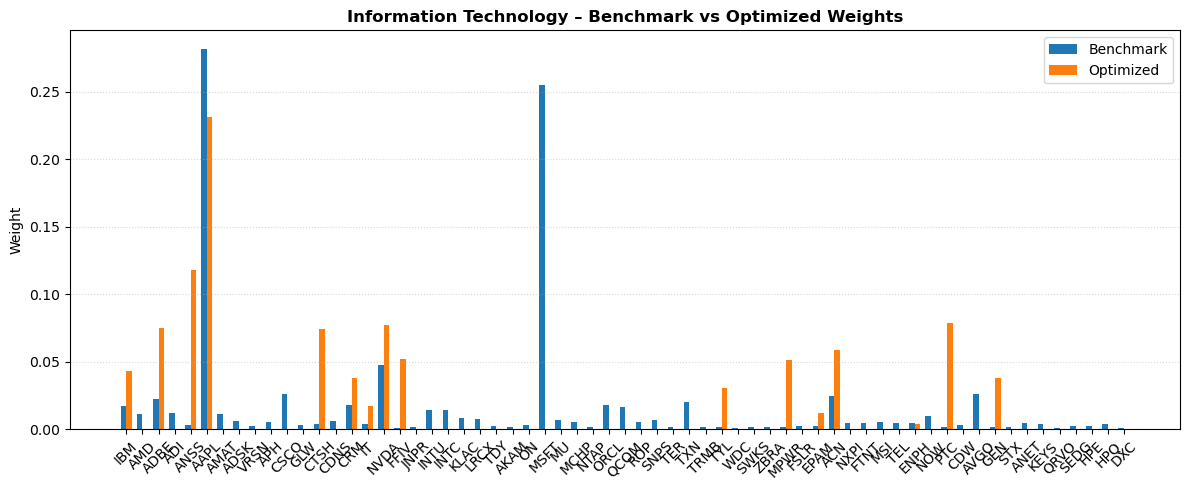

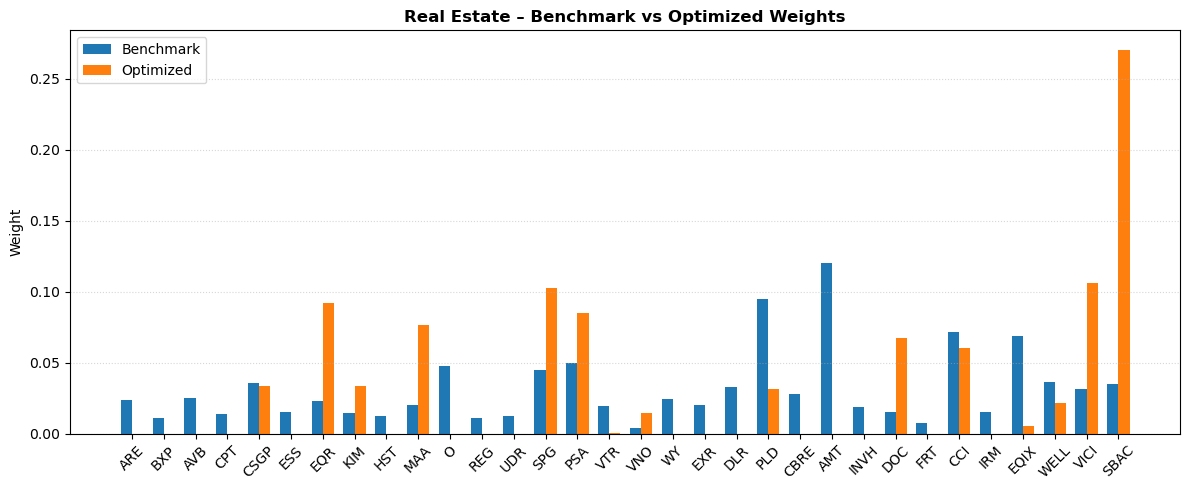

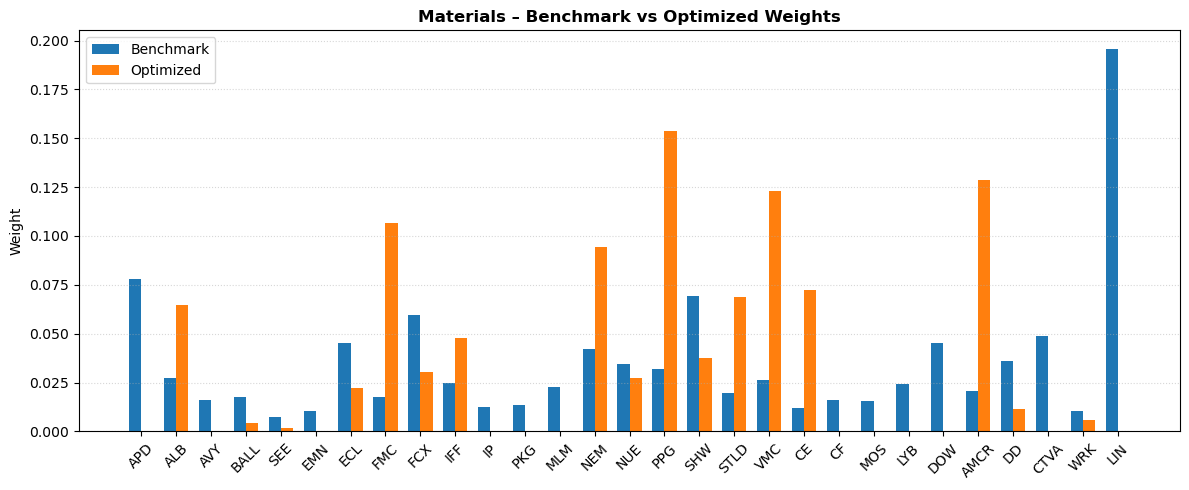

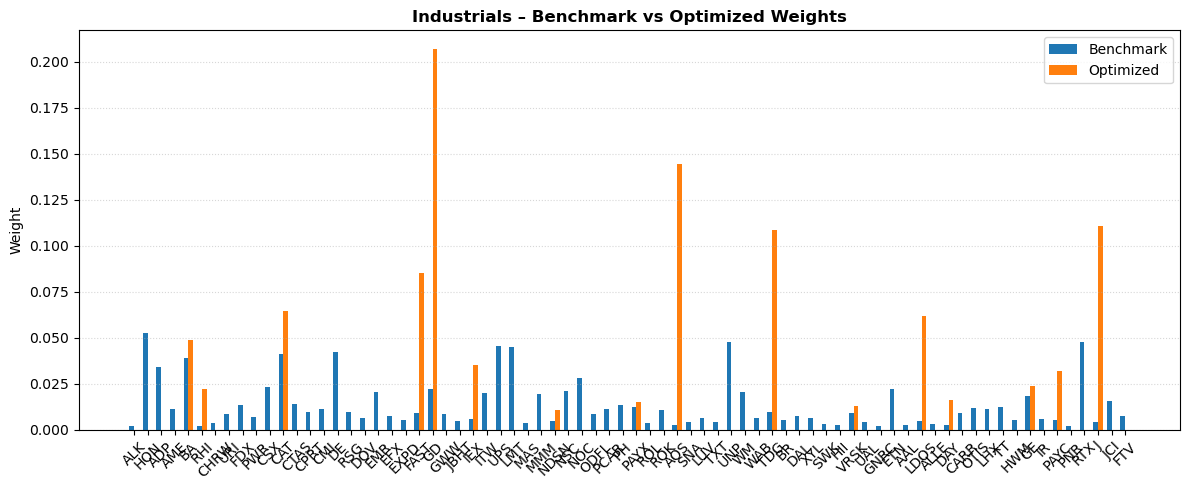

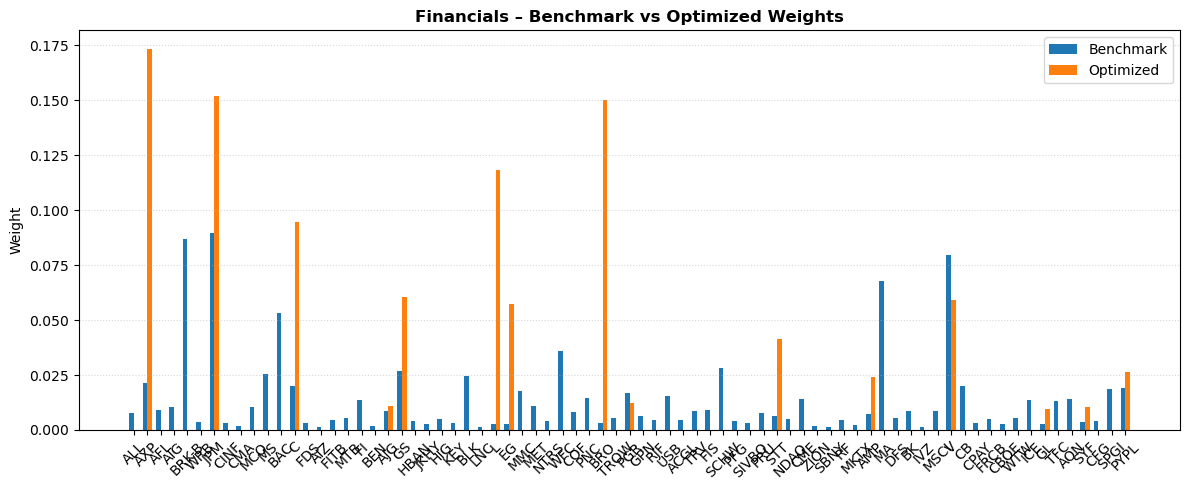

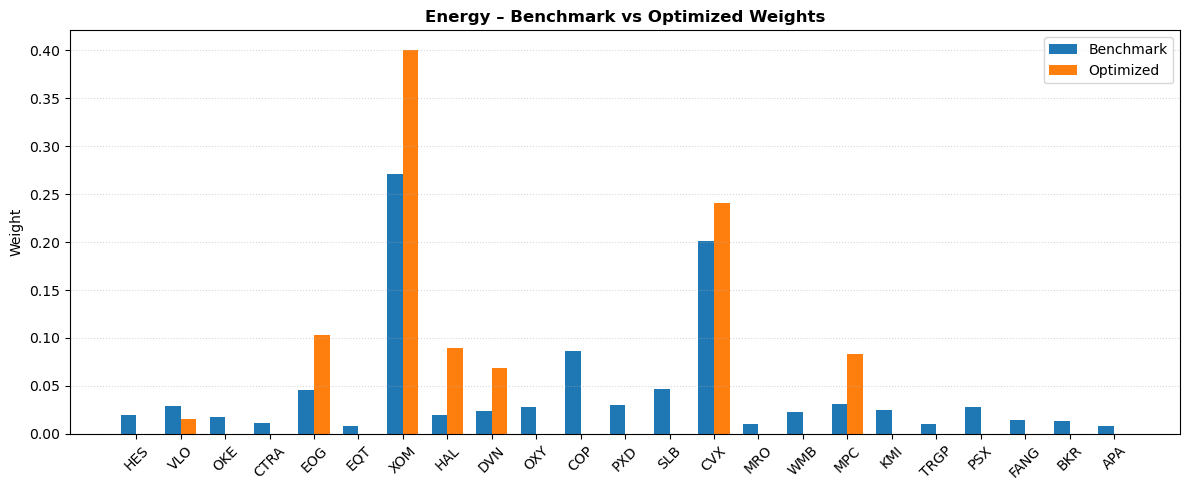

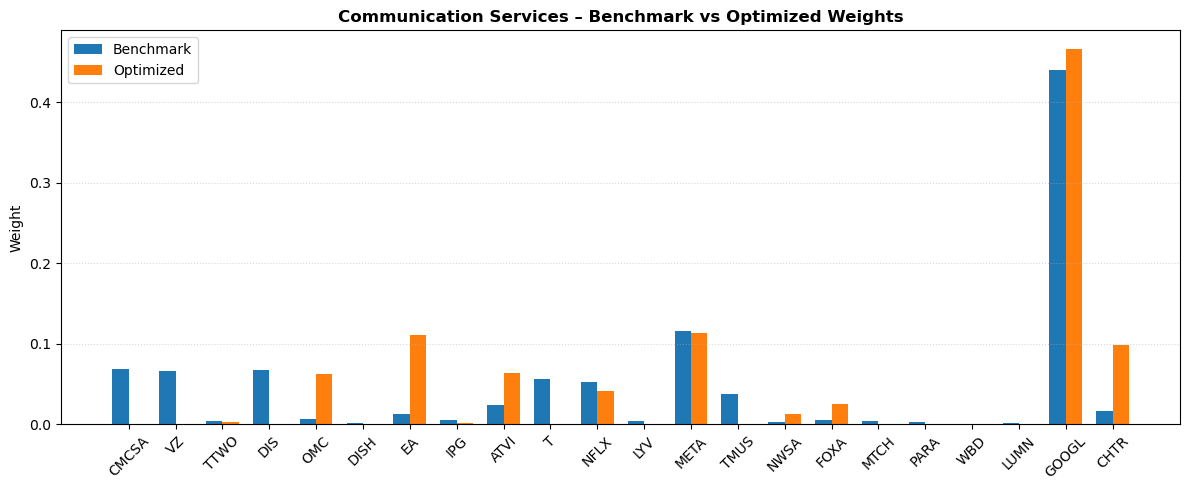

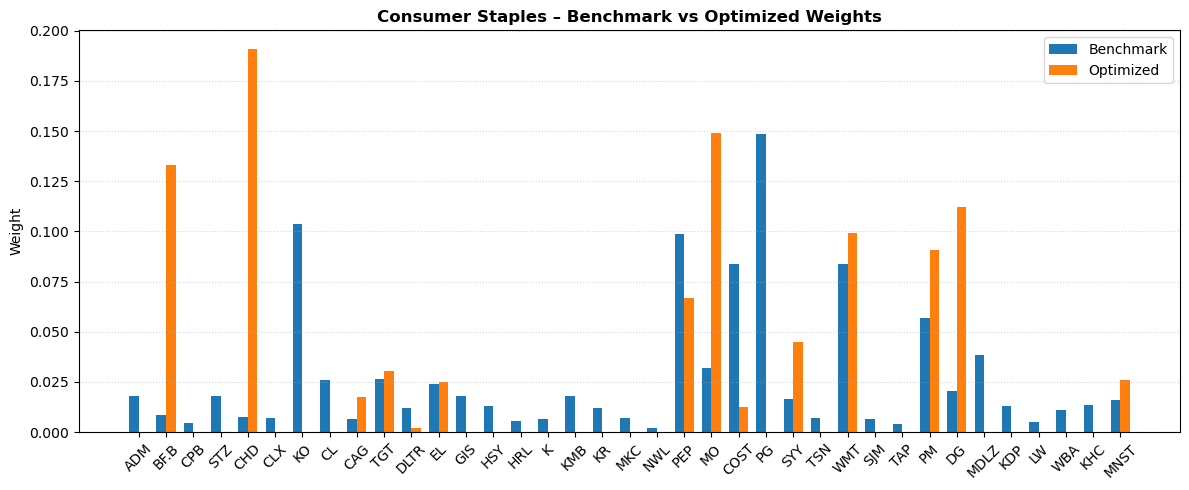

In [3]:
data = pd.read_excel("Data/dataset_comp_1222.xlsx")
diagnostics = []

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negative eigenvalues
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

# Raw Sigma from empirical returns
def sigma_raw_fn(R_clean):
    Sigma_sector = R_clean.cov()
    return Sigma_sector



sector_weights = {} 
optimal_portfolios = {}

for sector_name in data['GICS Sector'].unique():
    sector = data.loc[data['GICS Sector'] == sector_name]



    # Benchmark weights (should sum to 1)
    w_b_sector = sector[['weight_in_sector']]
    assert np.isclose(w_b_sector.sum().values[0], 1.0), f"{sector_name}: weights don't sum to 1"

    # Carbon intensities
    c_sector = sector[['Carbon Intensity']]
    assert c_sector.isna().sum().values[0] == 0, f"{sector_name}: carbon data has NaNs"

    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()
    stock_labels = R_clean.columns
    Sigma_sector= sigma_raw_fn(R_clean)
    Sigma_sector = nearest_psd(Sigma_sector)
    eigvals = np.linalg.eigvalsh(Sigma_sector)
    rank = np.linalg.matrix_rank(Sigma_sector)
    num_features = Sigma_sector.shape[1]


    # Convert covariance matrix to correlation matrix
    stddev = np.sqrt(np.diag(Sigma_sector))
    corr_matrix = Sigma_sector / np.outer(stddev, stddev)
    

   

    # Inputs
    N = len(w_b_sector)
    w_b_vec = w_b_sector.values.flatten()
    c_vec = c_sector.values.flatten()
    
   
    sector_weights[sector_name] = {
    'weights_by_te': [],         # list of np.array
    'tracking_errors': [],
    'carbon_reductions': [],
    'w_b_vec': w_b_vec,
    'stock_labels': list(stock_labels),  
    'relative_deltas':[]
    }
    # TE caps and results
    te_caps_annual = np.linspace(0.002, 0.05, 100)  # up to 10% TE
 
    tracking_errors = []
    carbon_reductions = []
    smallest_eigs = np.sort(eigvals)[:5]
    diagnostics.append({
        "Sector": sector_name,
        "Num Features": num_features,
        "Rank": rank,
        "Min_Eigval1": smallest_eigs[0],
        "Min_Eigval2": smallest_eigs[1] if len(smallest_eigs) > 1 else np.nan,
        "Min_Eigval3": smallest_eigs[2] if len(smallest_eigs) > 2 else np.nan,
        "Min_Eigval4": smallest_eigs[3] if len(smallest_eigs) > 3 else np.nan,
        "Min_Eigval5": smallest_eigs[4] if len(smallest_eigs) > 4 else np.nan,
        "Low Rank?": rank < num_features,
        "Not PSD?": eigvals.min() < -1e-6
    })
    for te_annual in te_caps_annual:
        # Convert to monthly variance
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2

        # Optimization
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, psd_wrap(Sigma_sector))
        constraints = [
            tracking_error <= te_cap_var_monthly,
            cp.sum(w) == 1,
            w >= 0,
        ]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)
        # Check if solution is usable
        if prob.status in ["optimal", "optimal_inaccurate"] and w.value is not None:
            pass
        else:
            print("Optimization failed or unreliable:", prob.status)
        w_opt = w.value
        if w_opt is not None:
            # Ex-post tracking error (annualized)
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            tracking_errors.append(te_real * 10000)  # in bps

            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
            carbon_reductions.append(reduction_pct)
            sector_weights[sector_name]['weights_by_te'].append(w_opt)
            sector_weights[sector_name]['tracking_errors'].append(te_real * 10000)
            sector_weights[sector_name]['carbon_reductions'].append(reduction_pct)



   
        if np.round(te_annual, 3) == 0.02:
            optimal_portfolios[sector_name] = {
            "w_b_vec": w_b_vec,
            "w_opt": w.value,
            "stock_labels": stock_labels}

    # Define the tracking error breakpoints (in bps)
    absolute_te_points = [100, 200, 300, 400, 500]
    relative_te_points = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

    tracking_errors_np = np.array(tracking_errors)
    carbon_reductions_np = np.array(carbon_reductions)

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df = diagnostics_df.sort_values("Sector")  # optional

print(tabulate(diagnostics_df, headers='keys', tablefmt='github', showindex=False))

# Custom sector order
ordered_sectors = [
    "Industrials",
    "Financials",
    "Consumer Discretionary",
    "Health Care",
    "Information Technology",
    "Consumer Staples",
    "Energy",
    "Materials",
    "Real Estate",
    "Utilities",
    "Communication Services"
]

plt.figure(figsize=(12, 6))  # Wider figure helps with spacing

for sector_name in ordered_sectors:
    if sector_name in sector_weights:
        metrics = sector_weights[sector_name]
        plt.plot(metrics['tracking_errors'], metrics['carbon_reductions'], label=sector_name)

plt.xlabel('Tracking Error (bps)')
plt.ylabel('Carbon Reduction (%)')
plt.title('TE–Carbon Frontier for All Sectors')

# Legend outside right
plt.legend(title="Sectors", loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()  # Adjust layout to fit legend
plt.show()


plot_te_carbon_heatmap(sector_weights=sector_weights, te_caps_annual=te_caps_annual)

for sector_name, data in optimal_portfolios.items():
    plot_origin_vs_opt_weights_comparison(
        data["w_b_vec"],
        data["w_opt"],
        data["stock_labels"],
        sector_name=sector_name,
        weight_comp_bool=True
    )

# TE - CARBON FRONTIERS WITH COVARIANCE REGULARIZATION
Ledoit-Wolf shrinkage + clipping eigenvalues + λI regularization:

| Sector                 |   Num Features |   Rank |   Min_Eigval1 |   Min_Eigval2 |   Min_Eigval3 |   Min_Eigval4 |   Min_Eigval5 | Low Rank?   | Not PSD?   |
|------------------------|----------------|--------|---------------|---------------|---------------|---------------|---------------|-------------|------------|
| Communication Services |             22 |     22 |   0.0041907   |   0.00420315  |   0.00425675  |   0.00435709  |   0.00444431  | False       | False      |
| Consumer Discretionary |             52 |     52 |   0.00233388  |   0.00233388  |   0.00233388  |   0.00233388  |   0.00233388  | False       | False      |
| Consumer Staples       |             37 |     37 |   0.00128617  |   0.00128617  |   0.00128617  |   0.00128617  |   0.00128617  | False       | False      |
| Energy                 |             23 |     23 |   0.00177144  |   0.00177756  |   0.0018155   |   0.00182917  |   0.00195003  | False       | False      |
| Financials             |             7

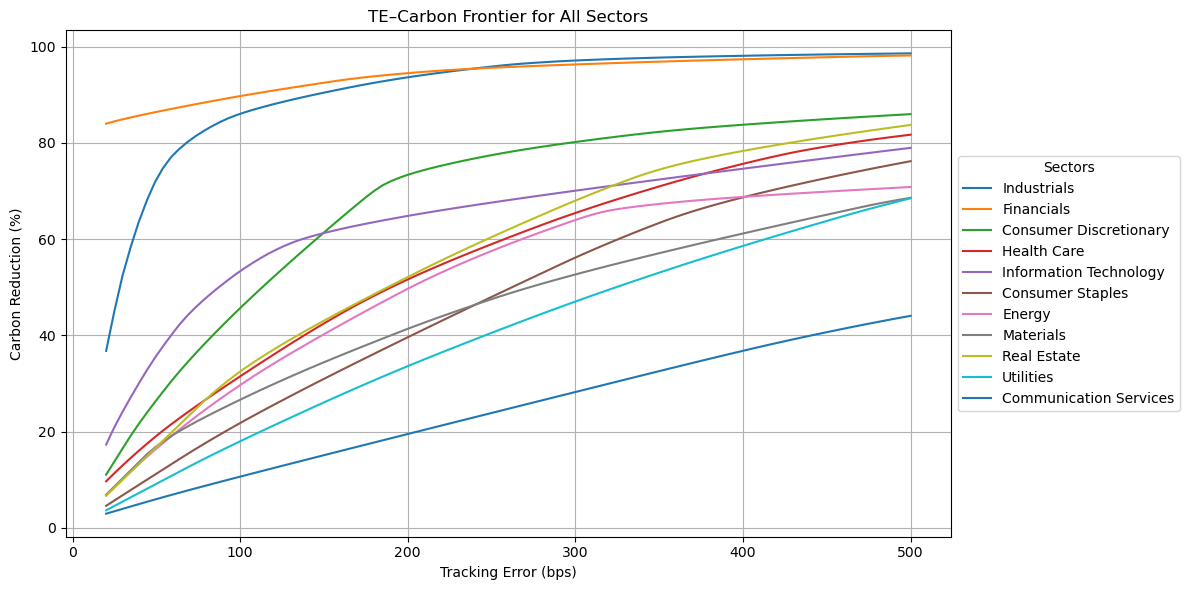

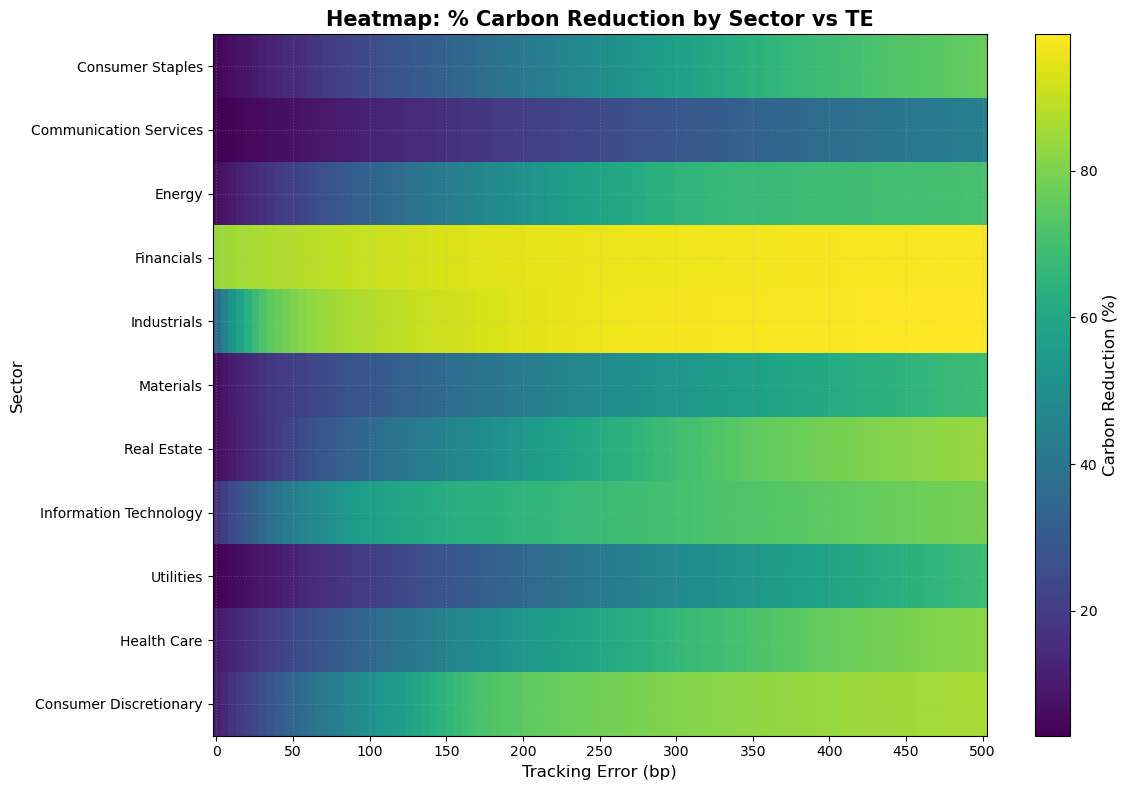

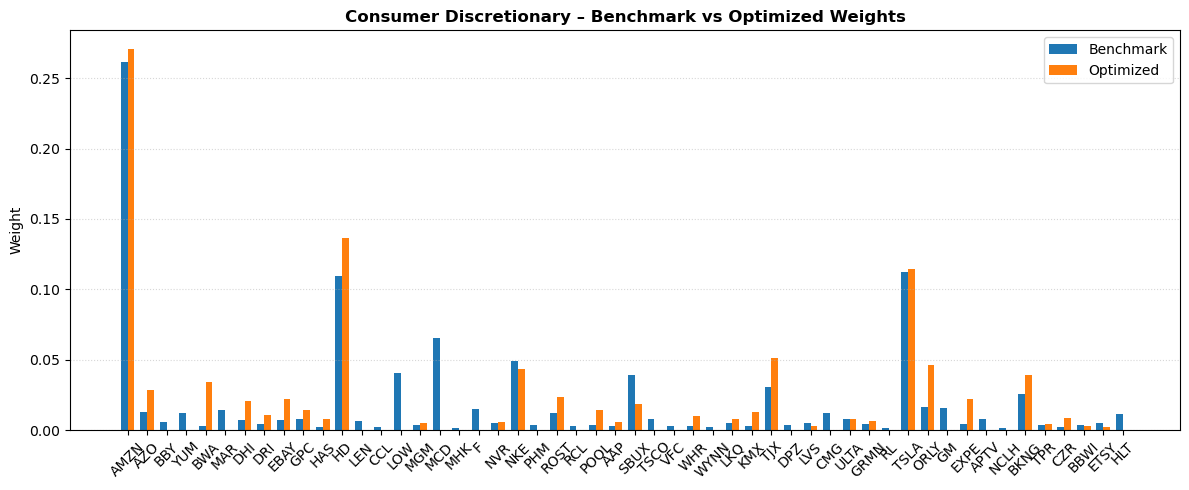

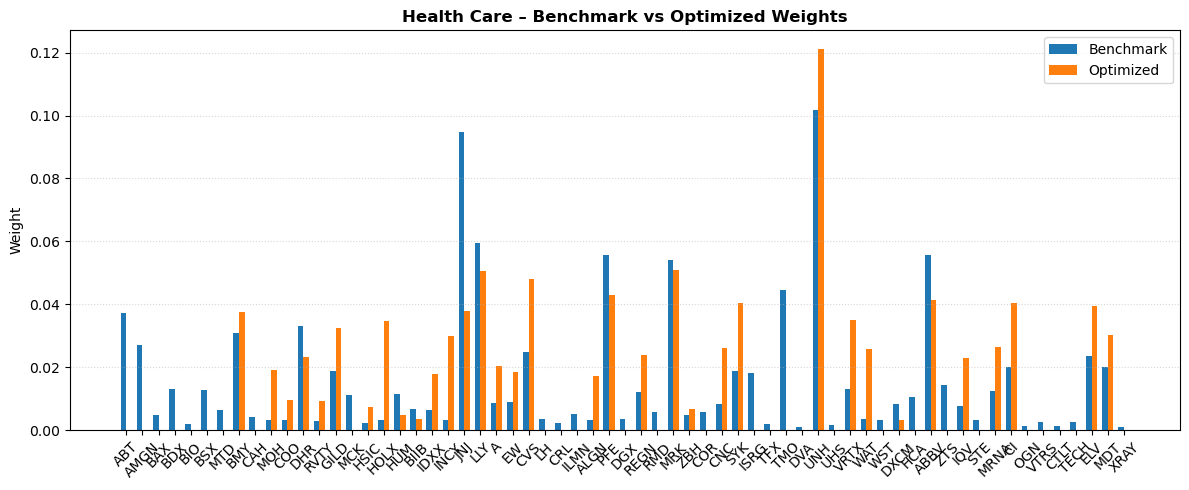

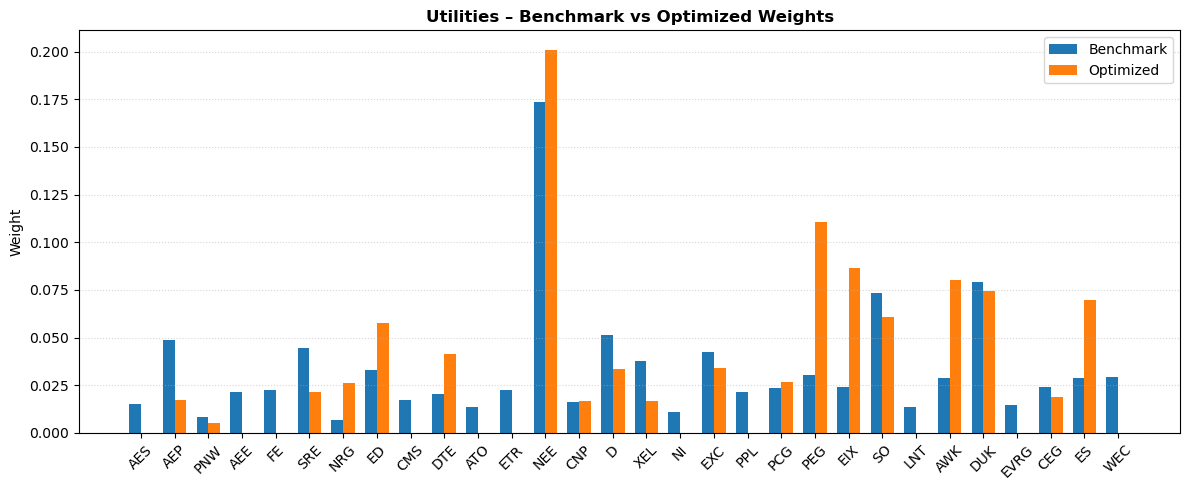

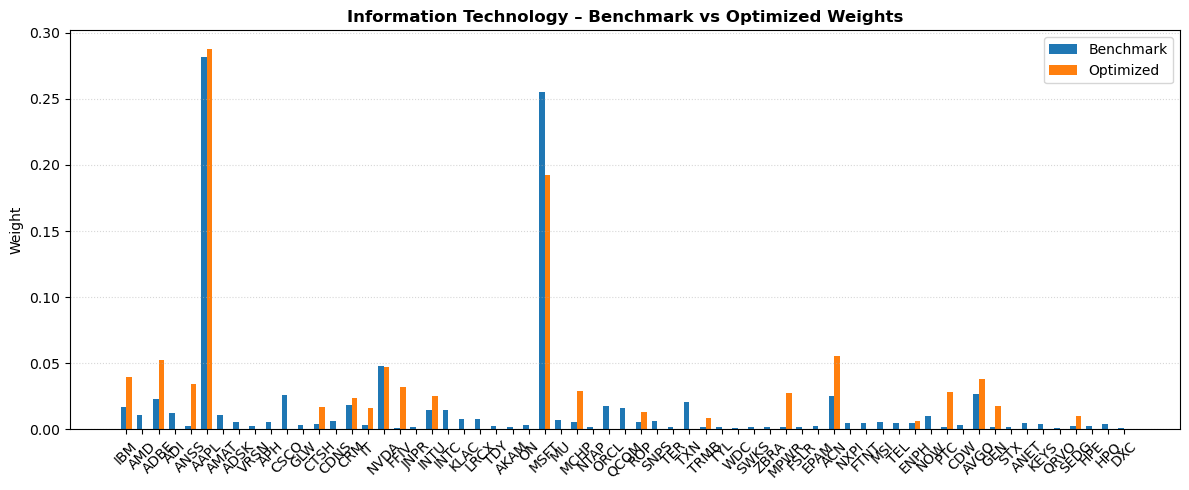

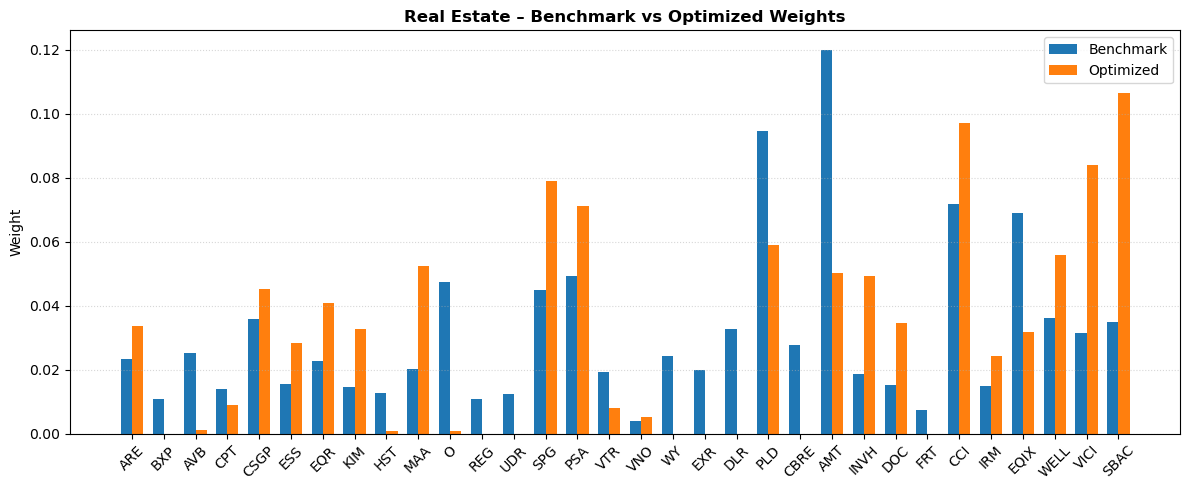

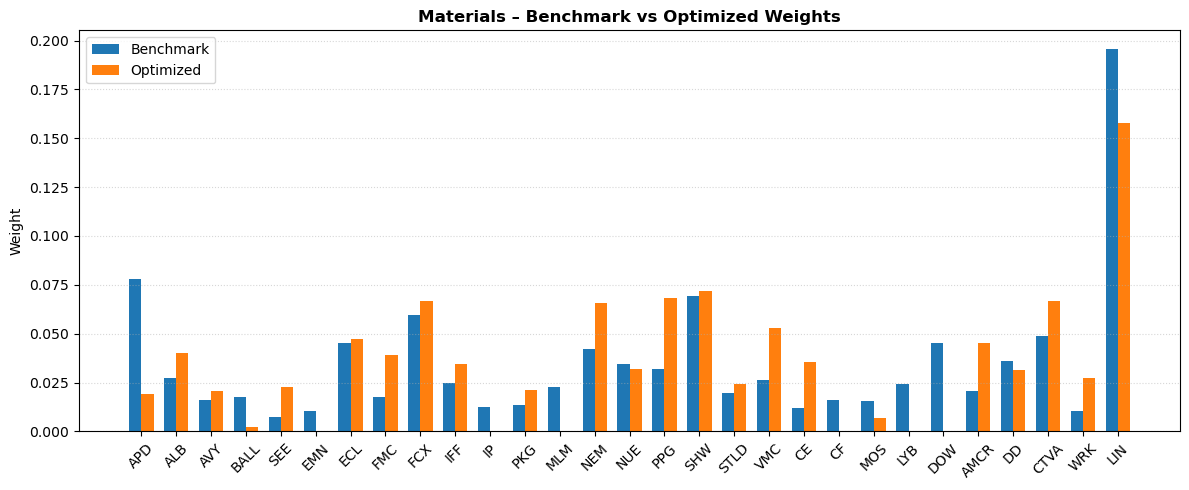

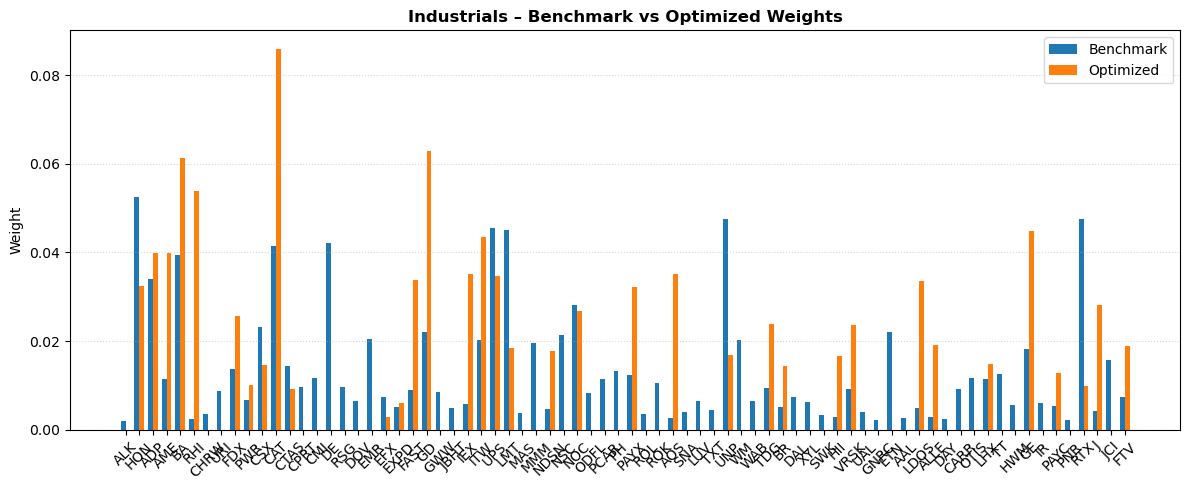

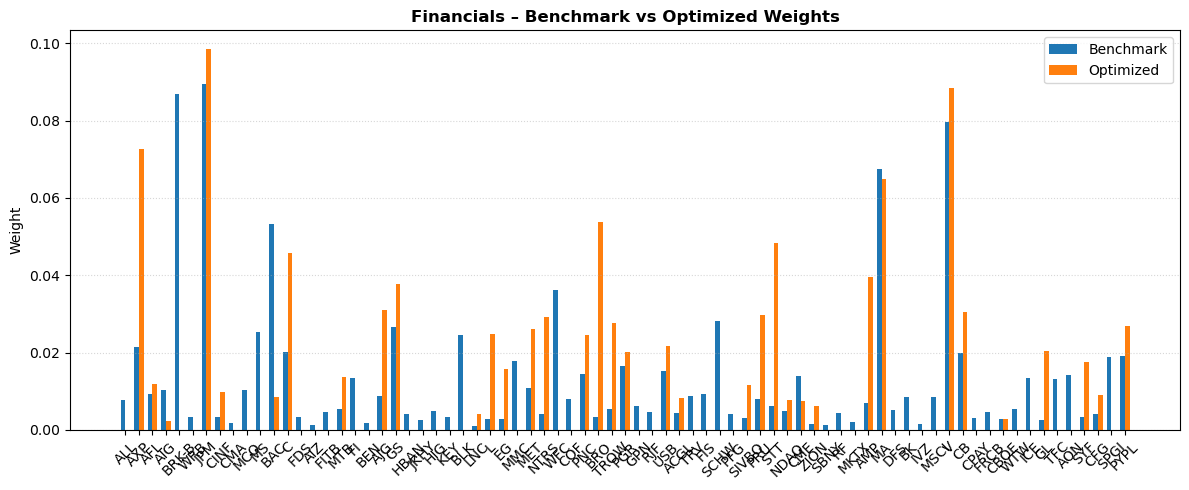

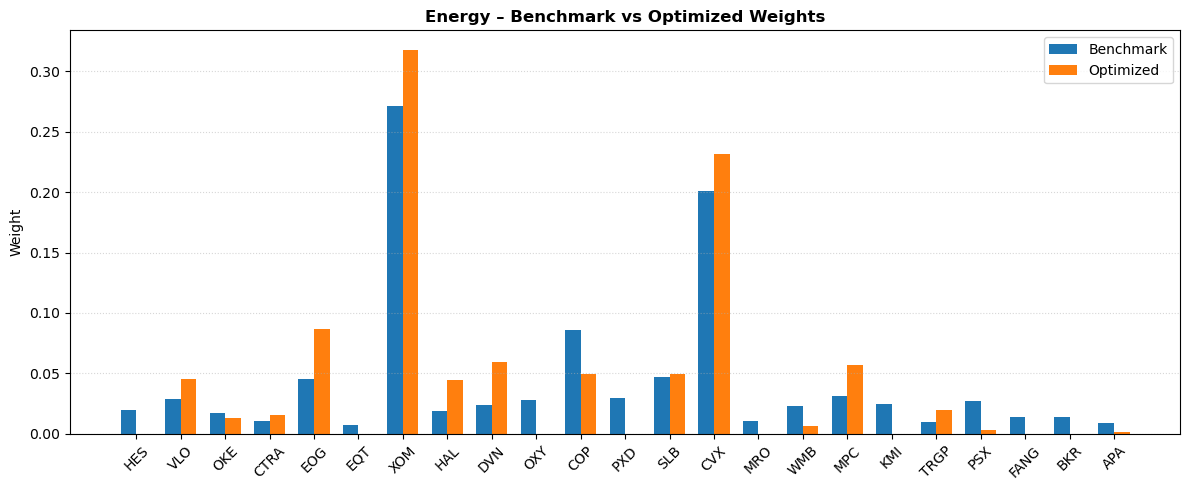

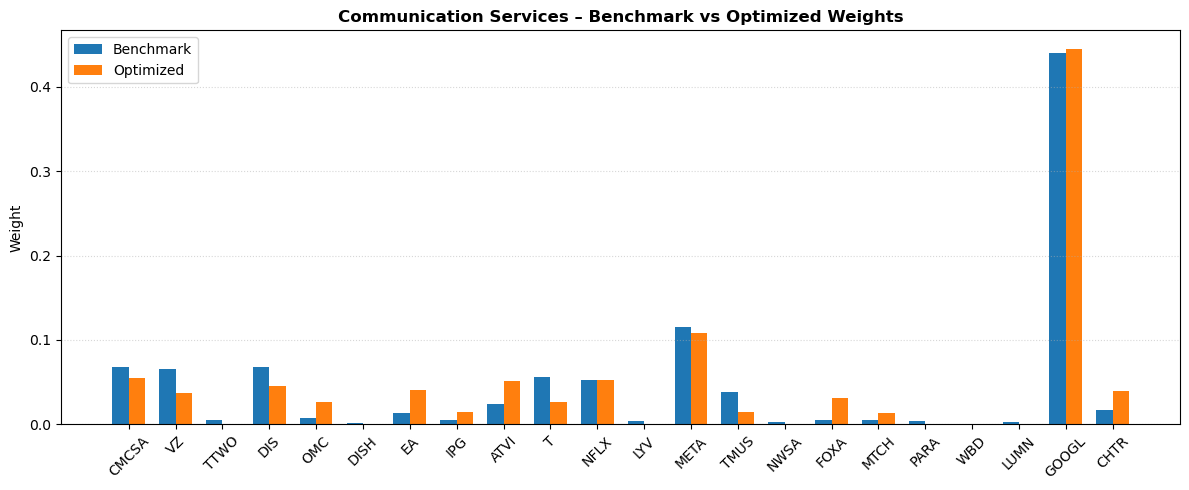

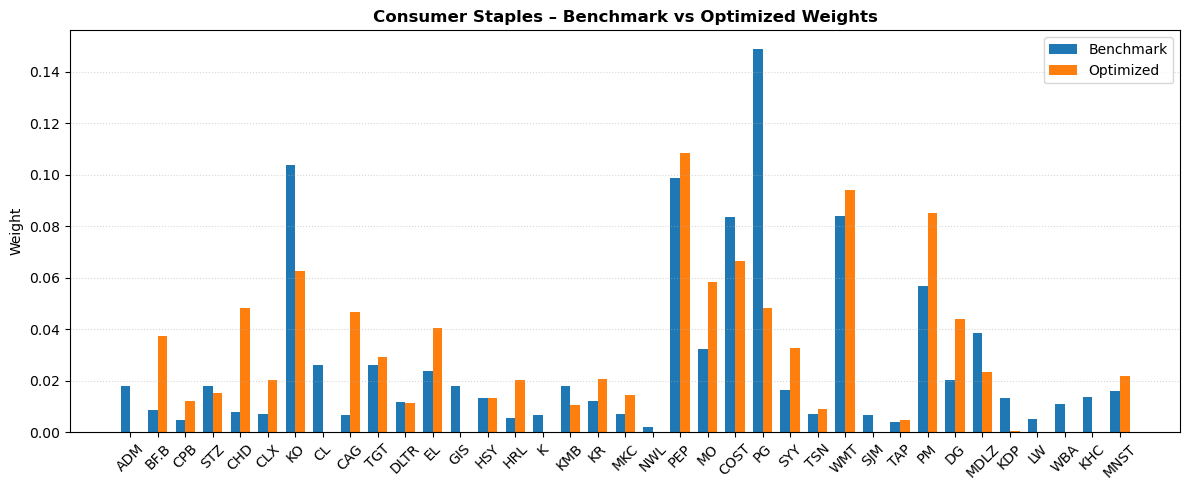

In [4]:
# Load data
# Regularized Sigma (shrinkage + lambda_I + nearest PSD)
def sigma_reg_fn(R_clean):

    # Apply Ledoit-Wolf shrinkage
    lw = LedoitWolf().fit(R_clean)
    Sigma_shrink = lw.covariance_

    # --- λI regularization ---
    lambda_I = 1e-5
    Sigma_reg = Sigma_shrink + lambda_I * np.eye(Sigma_shrink.shape[0])
    return Sigma_reg

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negative eigenvalues
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

data = pd.read_excel("Data/dataset_comp_1222.xlsx")

sector_weights = {} 
optimal_portfolios_shrink = {}
diagnostics = []

for sector_name in data['GICS Sector'].unique():
    sector_weights[sector_name] = {
    'weights_by_te': [],
    'tracking_errors': [],
    'carbon_reductions': [],
    'relative_deltas': [],
    }
    sector = data.loc[data['GICS Sector'] == sector_name]

    w_b_sector = sector[['weight_in_sector']]
    assert np.isclose(w_b_sector.sum().values[0], 1.0), f"{sector_name}: weights don't sum to 1"

    c_sector = sector[['Carbon Intensity']]
    assert c_sector.isna().sum().values[0] == 0, f"{sector_name}: carbon data has NaNs"
    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    
    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()
    stock_labels = R_clean.columns
    Sigma_sector = sigma_reg_fn(R_clean)
    Sigma_sector = nearest_psd(Sigma_sector)

    eigvals = np.linalg.eigvalsh(Sigma_sector)
    rank = np.linalg.matrix_rank(Sigma_sector)
    num_features = Sigma_sector.shape[1]
   
    # Prepare optimization inputs
    N = len(w_b_sector)
    w_b_vec = w_b_sector.values.flatten()
    c_vec = c_sector.values.flatten()

    te_caps_annual = np.linspace(0.002, 0.05, 100)
    tracking_errors = []
    carbon_reductions = []
    smallest_eigs = np.sort(eigvals)[:5]

    diagnostics.append({
        "Sector": sector_name,
        "Num Features": num_features,
        "Rank": rank,
        "Min_Eigval1": smallest_eigs[0],
        "Min_Eigval2": smallest_eigs[1] if len(smallest_eigs) > 1 else np.nan,
        "Min_Eigval3": smallest_eigs[2] if len(smallest_eigs) > 2 else np.nan,
        "Min_Eigval4": smallest_eigs[3] if len(smallest_eigs) > 3 else np.nan,
        "Min_Eigval5": smallest_eigs[4] if len(smallest_eigs) > 4 else np.nan,
        "Low Rank?": rank < num_features,
        "Not PSD?": eigvals.min() < -1e-6
    })
    for te_annual in te_caps_annual:
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma_sector))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if prob.status in ["optimal", "optimal_inaccurate"] and w.value is not None:
            w_opt = w.value
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100

            tracking_errors.append(te_real * 10000)
            carbon_reductions.append(reduction_pct)
        else:
            print(f"{sector_name}: Optimization failed at TE cap {te_annual:.3%}")
        w_opt = w.value
        if w_opt is not None:
            # Ex-post tracking error (annualized)
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            tracking_errors.append(te_real * 10000)  # in bps

            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
            carbon_reductions.append(reduction_pct)
            sector_weights[sector_name]['weights_by_te'].append(w_opt)
            sector_weights[sector_name]['tracking_errors'].append(te_real * 10000)
            sector_weights[sector_name]['carbon_reductions'].append(reduction_pct)

        
        cov_sector = pd.read_excel("Data/sector_cov_matrices_comp_1222.xlsx", sheet_name=sector_name)



        if np.round(te_annual, 3) == 0.02:
            optimal_portfolios_shrink[sector_name] = {
            "w_b_vec": w_b_vec,
            "w_opt": w.value,
            "stock_labels": stock_labels}
    # Define the tracking error breakpoints (in bps)
    absolute_te_points = [100, 200, 300, 400, 500]
    relative_te_points = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

    tracking_errors_np = np.array(tracking_errors)
    carbon_reductions_np = np.array(carbon_reductions)
    #plot_te_carbon_by_sector(tracking_errors=tracking_errors, carbon_reductions=carbon_reductions, tracking_errors_np=tracking_errors_np)

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df = diagnostics_df.sort_values("Sector")  # optional

print(tabulate(diagnostics_df, headers='keys', tablefmt='github', showindex=False))

# Custom sector order
ordered_sectors = [
    "Industrials",
    "Financials",
    "Consumer Discretionary",
    "Health Care",
    "Information Technology",
    "Consumer Staples",
    "Energy",
    "Materials",
    "Real Estate",
    "Utilities",
    "Communication Services"
]

plt.figure(figsize=(12, 6))  # Wider figure helps with spacing

for sector_name in ordered_sectors:
    if sector_name in sector_weights:
        metrics = sector_weights[sector_name]
        plt.plot(metrics['tracking_errors'], metrics['carbon_reductions'], label=sector_name)

plt.xlabel('Tracking Error (bps)')
plt.ylabel('Carbon Reduction (%)')
plt.title('TE–Carbon Frontier for All Sectors')

# Legend outside right
plt.legend(title="Sectors", loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()  # Adjust layout to fit legend
plt.show()

plot_te_carbon_heatmap(sector_weights=sector_weights, te_caps_annual=te_caps_annual)
for sector_name, data in optimal_portfolios_shrink.items():
    plot_origin_vs_opt_weights_comparison(
        data["w_b_vec"],
        data["w_opt"],
        data["stock_labels"],
        sector_name=sector_name,
        weight_comp_bool=True
    )

# Weight Perturbation Sensitivity – Before and After
Answering to the question: "Which sectors deliver robust solutions under changing input assumptions?"

In [22]:
def compute_perturbed_weights(
    R_clean,         # T x N clean return matrix
    w_b_vec,         # benchmark weights
    c_vec,           # carbon intensities
    Sigma_fn,        # function to generate Sigma (e.g., raw, shrinked, regularized)
    te_cap=0.02,     # TE cap (annual)
    n_trials=10,     # number of perturbations
    noise_std=0.01   # std dev of Gaussian noise
):
    N = R_clean.shape[1]
    te_cap_var_monthly = (te_cap / np.sqrt(12)) ** 2
    perturbations = []

    for seed in range(n_trials):
        np.random.seed(seed)
        noise = np.random.normal(0, noise_std, R_clean.shape)
        R_perturbed = R_clean + noise
        Sigma = Sigma_fn(R_perturbed)

        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, cp.psd_wrap(Sigma))
        constraints = [tracking_error <= te_cap_var_monthly, cp.sum(w) == 1, w >= 0]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        if w.value is not None and prob.status in ["optimal", "optimal_inaccurate"]:
            perturbations.append(w.value)
        else:
            perturbations.append(np.full(N, np.nan))  # or skip
    return np.array(perturbations)

data = pd.read_excel("Data/dataset_comp_1222.xlsx")

for sector_name in data['GICS Sector'].unique():
    
    
    R = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx", sheet_name=sector_name)
    

    # Drop the 'Date' column — keep only numeric log returns
    R_numeric = R.drop(columns=['Date'])
    R_clean = R_numeric.dropna()

    sector = data.loc[data['GICS Sector'] == sector_name]

    w_b_sector = sector[['weight_in_sector']]
    w_b_vec = w_b_sector.values.flatten()
    c_sector = sector[['Carbon Intensity']]
    c_vec = c_sector.values.flatten()
    
    # Use the same R_clean and optimization inputs as earlier
    w_pert_raw = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_raw_fn, te_cap=0.02)
    w_pert_reg = compute_perturbed_weights(R_clean, w_b_vec, c_vec, sigma_reg_fn, te_cap=0.02)

    # L1 distances from baseline
    baseline_w = w_b_vec
    l1_raw = [np.sum(np.abs(w - baseline_w)) for w in w_pert_raw if not np.isnan(w).any()]
    l1_reg = [np.sum(np.abs(w - baseline_w)) for w in w_pert_reg if not np.isnan(w).any()]

    sector_weights[sector_name]["l1_raw"] = l1_raw
    sector_weights[sector_name]["l1_reg"] = l1_reg

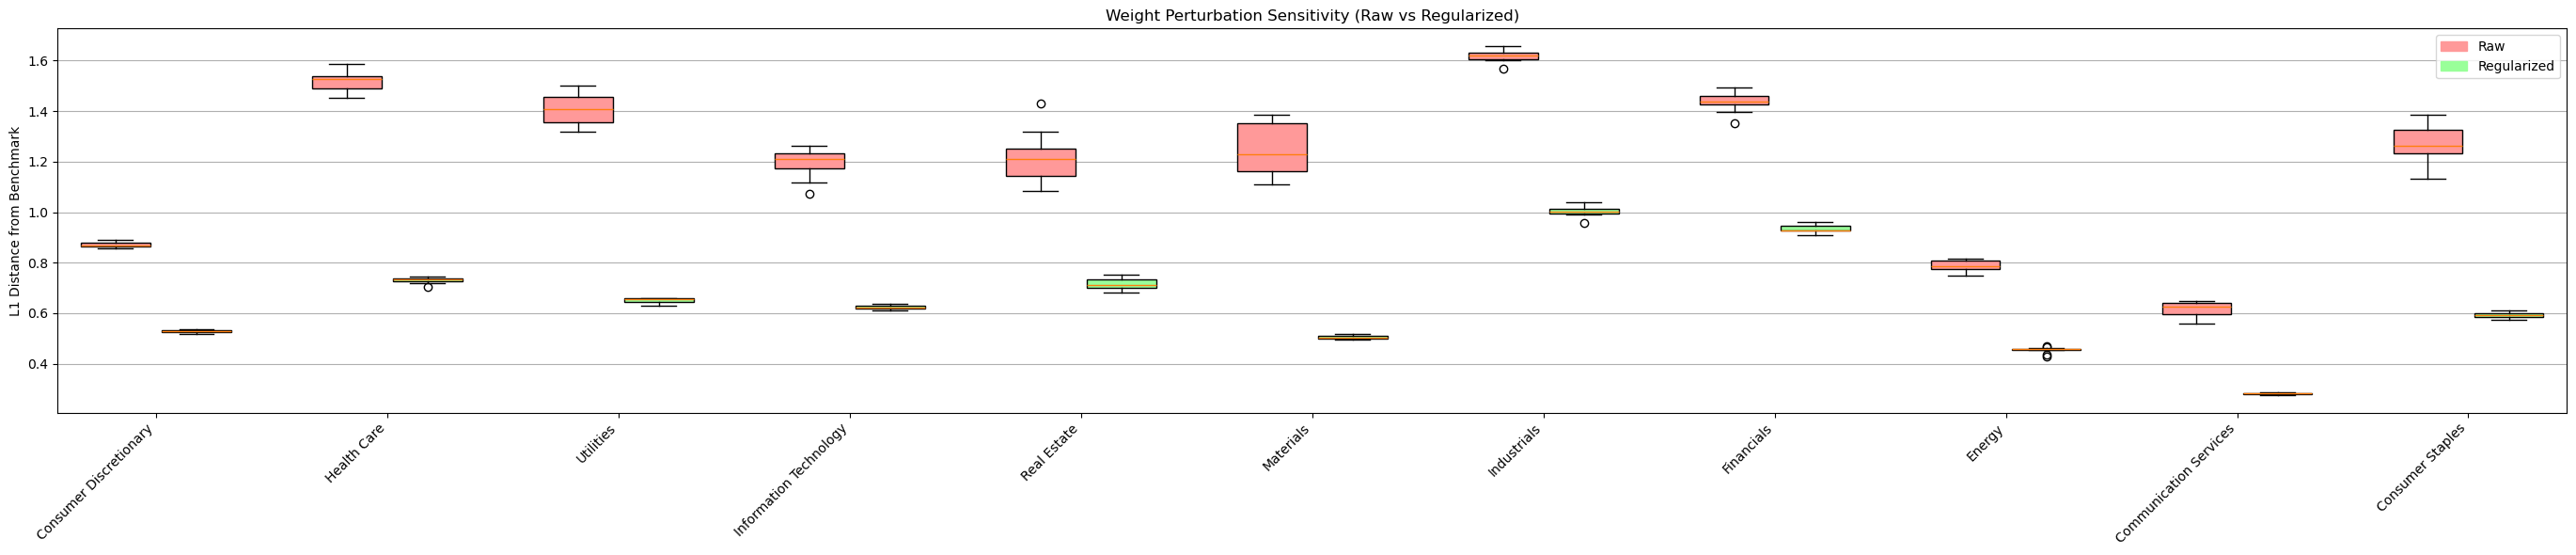

In [23]:
sectors = list(sector_weights.keys())
num_sectors = len(sectors)

fig, ax = plt.subplots(figsize=(2.5 * num_sectors, 6))

# Prepare data and positions
all_data = []
positions = []
labels = []
colors = []

for i, sector in enumerate(sectors):
    raw = sector_weights[sector]['l1_raw']
    reg = sector_weights[sector]['l1_reg']
    
    all_data.extend([raw, reg])
    positions.extend([2 * i, 2 * i + 0.7])
    labels.extend([f'{sector}\nRaw', 'Reg'])
    colors.extend(['#ff9999', '#99ff99'])  # light red, light green

# Plot boxplots
box = ax.boxplot(all_data, positions=positions, patch_artist=True, widths=0.6)

# Apply custom colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis
ax.set_xticks([2 * i + 0.35 for i in range(num_sectors)])
ax.set_xticklabels(sectors, rotation=45, ha='right')

# Labels and styling
ax.set_ylabel("L1 Distance from Benchmark")
ax.set_title("Weight Perturbation Sensitivity (Raw vs Regularized)")
ax.grid(True, axis='y')

# Legend manually
from matplotlib.patches import Patch
legend_patches = [Patch(color='#ff9999', label='Raw'), Patch(color='#99ff99', label='Regularized')]
ax.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.show()
